<div style="text-align: center;">

<img src="https://ascom.ufpa.br/images/Brasao/UFPA.png" width="120">

#### <b>UNIVERSIDADE FEDERAL DO PARÁ</b>
#### <b>CAMPUS UNIVERSITÁRIO DE TUCURUÍ</b> 
#### <b>FACULDADE DE ENGENHARIA ELÉTRICA</b>

</div>

#### Discente: Felipe Silveira Piano
#### Orientador: Rafael Suzuki Bayma

---
#### <div style="text-align: center;"><b>ANÁLISE DE ATRIBUTOS DE SINAIS DE VIBRAÇÃO PARA O DIAGNÓSTICO DE FALHAS EM ROLAMENTOS UTILIZANDO PCA E CLUSTERING HIERÁRQUICO</b></div>
---

### **Bibliotecas**

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.io import loadmat
from scipy.stats import kurtosis, skew
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree, to_tree
import pandas as pd
from sklearn.preprocessing import StandardScaler

### **Importação dos Dados**

In [36]:
# DIRETÓRIO PARA IMPORTAÇÃO DOS ARQUIVOS
DATA_PATH = "Bearings Dataset - CWRU/"

# NOME DOS ARQUIVOS NO DIRETÓRIO
DATA_COD = ['97.mat', '109.mat', '122.mat', '135.mat', '213.mat', '226.mat', '238.mat']

# CHAVES DE DICIONÁRIO PARA ACESSAR OS SINAIS APENAS DO LADO DO ACIONAMENTO 48kHz
POS_NAME = ['X097_DE_time', 'X109_DE_time', 'X122_DE_time', 'X135_DE_time', 'X213_DE_time', 'X226_DE_time', 'X238_DE_time']

In [37]:
#IMPORTAÇÃO DOS DADOS BRUTOS
dataset_raw = [loadmat(DATA_PATH + codigo) for codigo in DATA_COD ]

#SEPARAÇÃO DOS SINAIS QUE SERÃO ANÁLISADOS (DRIVE END)
dataset = [dataset_raw[i][pos_name].reshape(-1) for i, pos_name in enumerate(POS_NAME)]

### **Gráficos dos Sinais Brutos**

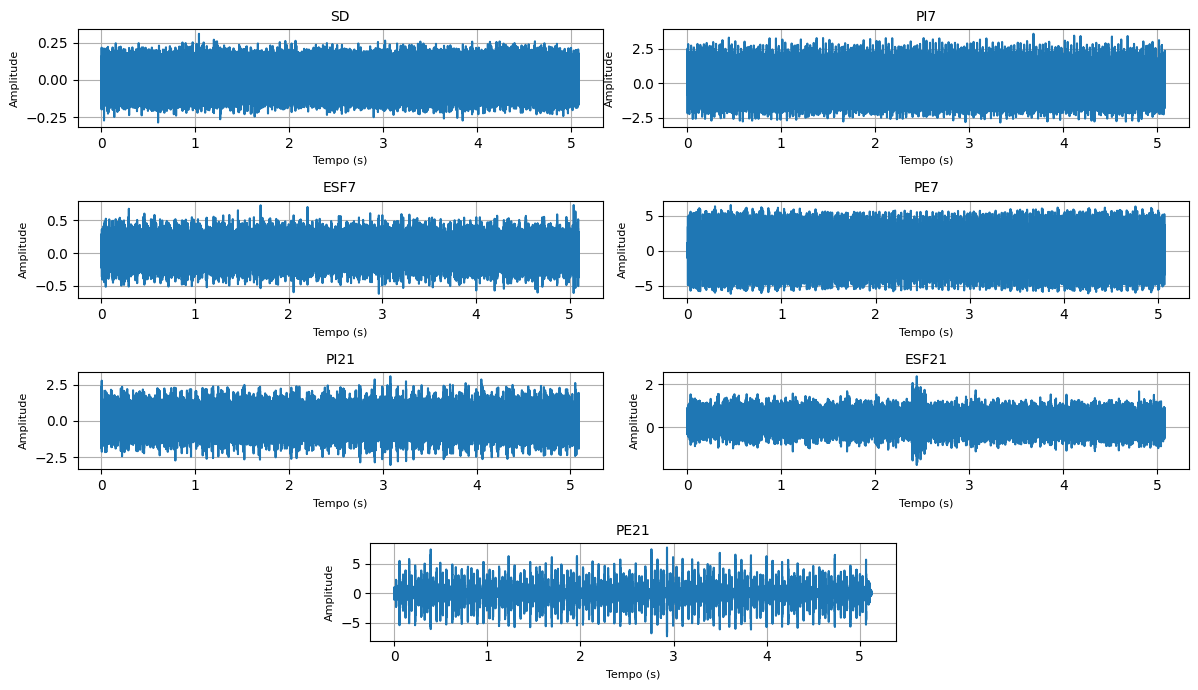

In [38]:
#LISTA ARMAZENANDO O NOME DE CADA GRÁFICO
classes = ['SD', 'PI7', 'ESF7', 'PE7', 'PI21', 'ESF21', 'PE21'] 

#TAXA DE AMOSTRAGEM DO SINAL DE VIBRAÇÃO
freq_amostragem = 48e3
period_amostragem = 1/freq_amostragem

#LAÇO PARA GERAR O GRÁFICO DE CADA SINAL DE VIBRAÇÃO
fig = plt.figure(figsize=(12,7))
gs = fig.add_gridspec(4, 4)
list_gs = [(0,slice(0,2)),(0,slice(2,4)),(1,slice(0,2)),(1,slice(2,4)),(2,slice(0,2)),(2,slice(2,4))]

for i, name in enumerate(classes):
    if i==6:
        ax = fig.add_subplot(gs[3,1:3])
    else:
        ax = fig.add_subplot(gs[list_gs[i]])

    tempo = np.linspace(0, len(dataset[i])/freq_amostragem, len(dataset[i]), endpoint=False)
    ax.plot(tempo, dataset[i])
    ax.set_xlabel('Tempo (s)', fontsize=8)
    ax.set_ylabel('Amplitude', fontsize=8)
    ax.set_title(classes[i], fontsize=10)
    ax.grid()
plt.tight_layout()
# plt.savefig('LaTeX/figuras/figura_34.pdf', format='pdf', bbox_inches='tight')
plt.show()

### **Processamento dos Sinais**

#### **Janelamento**

In [39]:
# FUNÇÃO PARA JANELAR O SINAL
def wind(sinal,tamanho,passo):
    if tamanho < passo:
        raise ValueError("Tamanho da janela precisa ser maior que o passo!")
    
    sinal_janelado = []

    n = 0
    while n*passo+tamanho <= sinal.size:
        sinal_janelado.append(sinal[n*passo : n*passo+tamanho])
        n += 1

    sinal_janelado = np.concatenate([sinal_janelado],axis=1)

    return sinal_janelado

In [40]:
# APLICA A FUNÇÃO wind PARA FAZER O JANELAMENTO
rpm = 1797

cage_train = 0.39828

FTF = cage_train*(rpm/60)

tamanho_janela = int(np.ceil((1/FTF)*freq_amostragem))

passo = tamanho_janela//2

# Lista que recebe os sinais janelados.
sinais_jan = [wind(sinal,tamanho_janela,passo) for sinal in dataset]

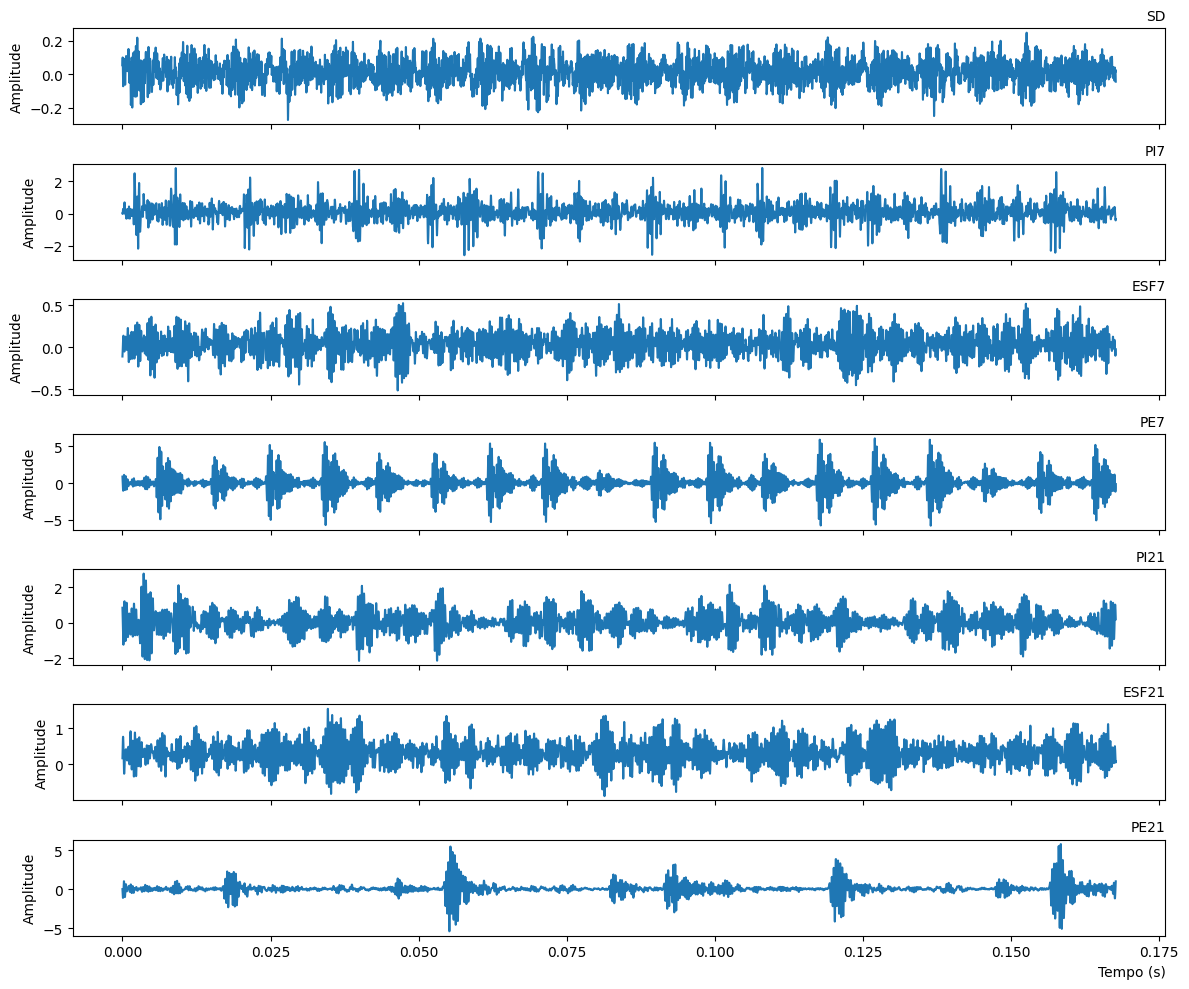

In [41]:
#LISTA ARMAZENANDO O NOME DE CADA GRÁFICO
classes = ['SD', 'PI7', 'ESF7', 'PE7', 'PI21', 'ESF21', 'PE21'] 

#TAXA DE AMOSTRAGEM DO SINAL DE VIBRAÇÃO
freq_amostragem = 48e3
period_amostragem = 1/freq_amostragem

#LAÇO PARA GERAR O GRÁFICO DE CADA JANELA
fig, axs = plt.subplots(nrows=7, figsize=(12,10), sharex=True)
for i in range(len(dataset)):
    tempo = np.linspace(0, len(dataset[i][0:2*tamanho_janela])/freq_amostragem, len(dataset[i][0:2*tamanho_janela]), endpoint=False)
    axs[i].plot(tempo, dataset[i][0:2*tamanho_janela])
    axs[i].set_title(classes[i], fontsize=10, loc='right')
    axs[i].set_ylabel('Amplitude', fontsize=10)
    # axs[i].grid()
plt.xlabel('Tempo (s)', fontsize=10, loc="right")
plt.tight_layout()
# plt.savefig('LaTeX/figuras/figura_35.pdf', format='pdf', bbox_inches='tight')
plt.show()

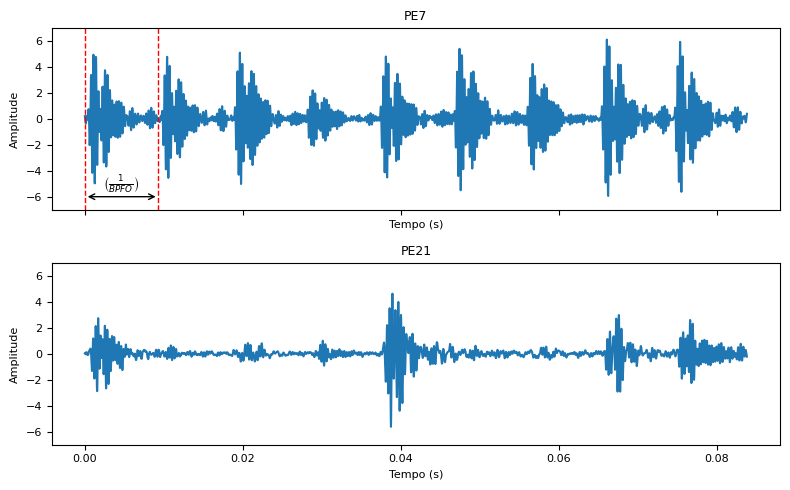

In [42]:
# GRÁFICO COMPARANDO AS JANELAS DE PE7 COM PE21

# Parâmetros para gerar os gráficos
tempo = np.linspace(0, sinais_jan[0].shape[1]/freq_amostragem, sinais_jan[0].shape[1], endpoint=False)
outer_ring = 3.5848
BPFO = outer_ring*(rpm/60)
inicio_periodo = 0
periodo = 1/BPFO
fim_periodo = inicio_periodo + periodo

fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(8,5), sharex=True)

# GRÁFICO DE PE7
ax1.plot(tempo, sinais_jan[3][116])
ax1.set_xlabel('Tempo (s)', fontsize=8)
ax1.set_ylabel('Amplitude', fontsize=8)
ax1.set_title(classes[3], fontsize=9)
ax1.axvline(x=inicio_periodo, color='red', linestyle='--', alpha=1, linewidth=1)
ax1.axvline(x=fim_periodo, color='red', linestyle='--', alpha=1, linewidth=1)

# Adicionar uma seta dupla indicando a largura do período
y_seta = -6 # Altura onde a seta e o texto vão aparecer
ax1.annotate('', 
            xy=(inicio_periodo, y_seta), 
            xytext=(fim_periodo, y_seta),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1))

# Adicionar o texto do período centralizado acima da seta
x_meio = (inicio_periodo + fim_periodo) / 2
ax1.text(x_meio, y_seta + 0.1, r'$\left( \frac{1}{BPFO} \right)$', 
        ha='center', va='bottom', fontsize=9, color='black')
ax1.tick_params(axis='both', labelsize=8)
ax1.set_ylim(-7, 7)
# ax1.grid()

# GRÁFICO DE PE21
ax2.plot(tempo, sinais_jan[6][116])
ax2.set_xlabel('Tempo (s)', fontsize=8)
ax2.set_ylabel('Amplitude', fontsize=8)
ax2.set_title(classes[6], fontsize=9)
ax2.tick_params(axis='both', labelsize=8)
ax2.set_ylim(-7, 7)
# ax2.grid()

plt.tight_layout()

# plt.savefig('LaTeX/figuras/figura_38.pdf', format='pdf', bbox_inches='tight')
plt.show()

#### **Criação de Rótulos**

In [43]:
# Gera os rótulos de cada classe
labels = np.concatenate([np.repeat(i,repeats=len(sinal)) for i, sinal in enumerate(sinais_jan)])

# Copia as labels para Y
Y = labels

In [44]:
# Gera os rótulos dos dados em formato categórico
labels_names = [classes[i] for i in Y]

In [45]:
# Condensa os sinais janelados em uma única matriz
X = np.concatenate(sinais_jan)

#### **Extração de Atributos**

In [46]:
# CÁLCULO DOS ATRIBUTOS
valor_rms = np.sqrt(np.mean(X**2,axis=1))

fator_de_crista = np.max(np.abs(X),axis=1)/valor_rms

fator_k = np.max(np.abs(X),axis=1)*valor_rms

assimetria = skew(X, axis=1)

curtose = kurtosis(X, axis=1, fisher=False)

# Condensa todos os atributos em uma única matriz
atributos = np.column_stack([valor_rms, fator_de_crista, fator_k, assimetria, curtose])

##### **Conversão para DataFrame**

In [47]:
# Lista com os nomes dos atributos estatísticos
atrib_names = ['Valor RMS', 'Fator de Crista', 'Fator K', 'Assimetria', 'Curtose']
# Criação de dataframe dos atributos para facilitar a manipulação
df_atributos = pd.DataFrame(atributos, columns=atrib_names)
# Adiciona Labels ao Dataframe
df_atributos['Labels'] = labels_names
# Exibir DataFrame
df_atributos

,Valor RMS,Fator de Crista,Fator K,Assimetria,Curtose,Labels
0,0.076274,3.577483,0.020813,-0.093781,2.894919,SD
1,0.076199,2.975970,0.017279,-0.022365,2.832920,SD
2,0.073171,3.407030,0.018241,-0.034498,2.852271,SD
3,0.072677,3.430194,0.018118,-0.108856,2.900946,SD
4,0.072300,3.107574,0.016244,-0.129229,2.858171,SD
...,...,...,...,...,...,...
836,0.644822,8.708824,3.621084,-0.451707,16.461957,PE21
837,0.584362,7.151690,2.442152,-0.173855,17.237479,PE21
838,0.625709,6.679106,2.614947,-0.371827,16.640425,PE21
839,0.762069,7.424791,4.311945,-0.061104,16.356083,PE21


#### **Gráficos dos Atributos**

##### **Diagrama de Caixa (Boxplot)**

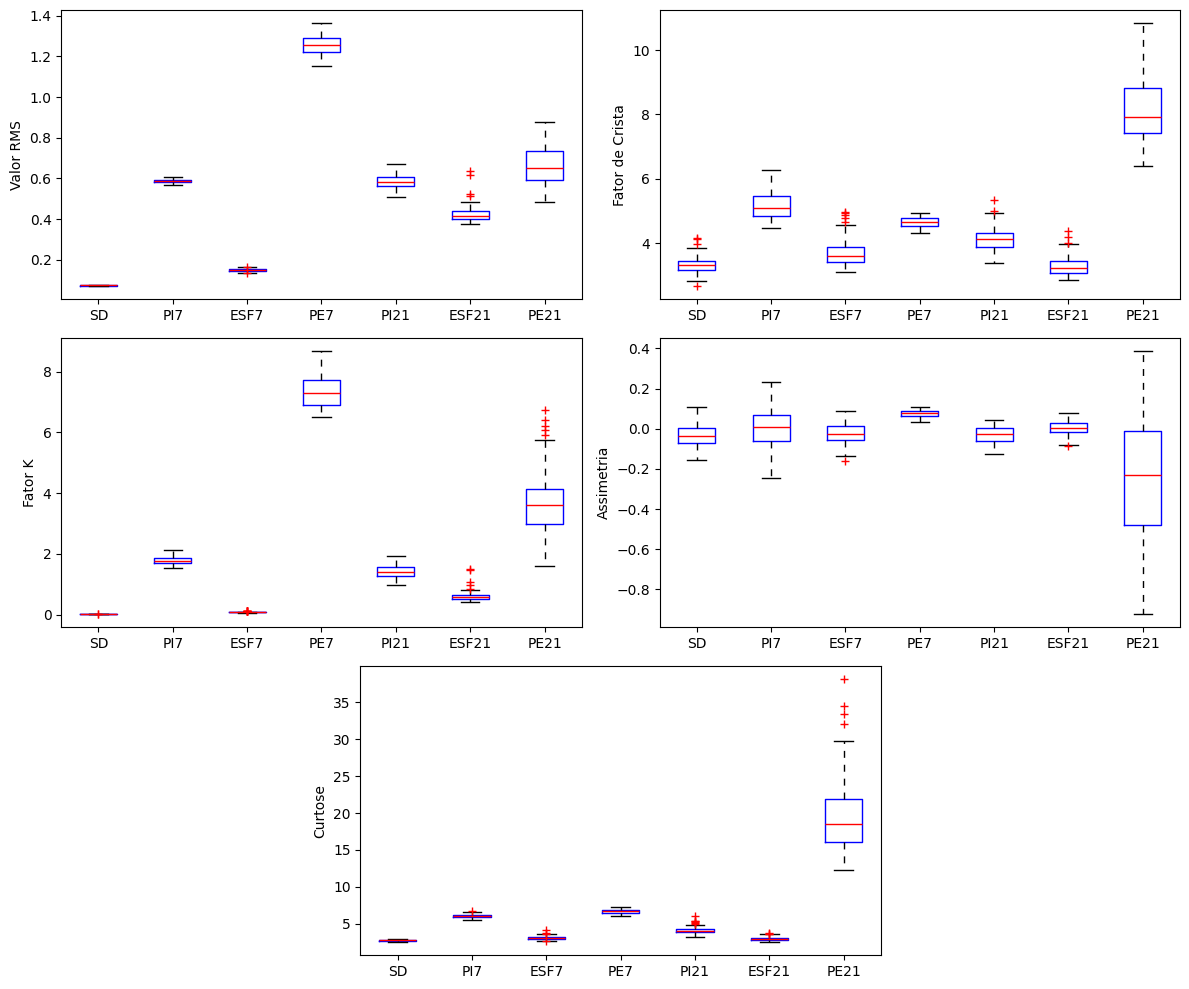

In [48]:
fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(3, 4)
list_gs = [(0,slice(0,2)),(0,slice(2,4)),(1,slice(0,2)),(1,slice(2,4))]
for i, name in enumerate(atrib_names):
    if i==4:
        ax = fig.add_subplot(gs[2,1:3])
    else:
        ax = fig.add_subplot(gs[list_gs[i]])

    boxplot = [atributos[np.array(labels_names)==j,i] for j in classes]
    ax.boxplot(boxplot, showfliers=True, 
                        tick_labels=classes, 
                        medianprops=dict(color='red', linewidth=1), 
                        boxprops=dict(color='blue', linewidth=1),
                        capprops=dict(linewidth=1), 
                        whiskerprops=dict(linestyle=(0, (5,5)),linewidth=1),
                        flierprops=dict(marker='+', markeredgecolor='red', markeredgewidth=1)
                )
    ax.set_ylabel(name, fontsize=10)
    ax.tick_params(axis='both', labelsize=10)
plt.tight_layout()
# plt.savefig('LaTeX/figuras/figura_37.pdf', format='pdf', bbox_inches='tight')
plt.show()

##### **Histograma**

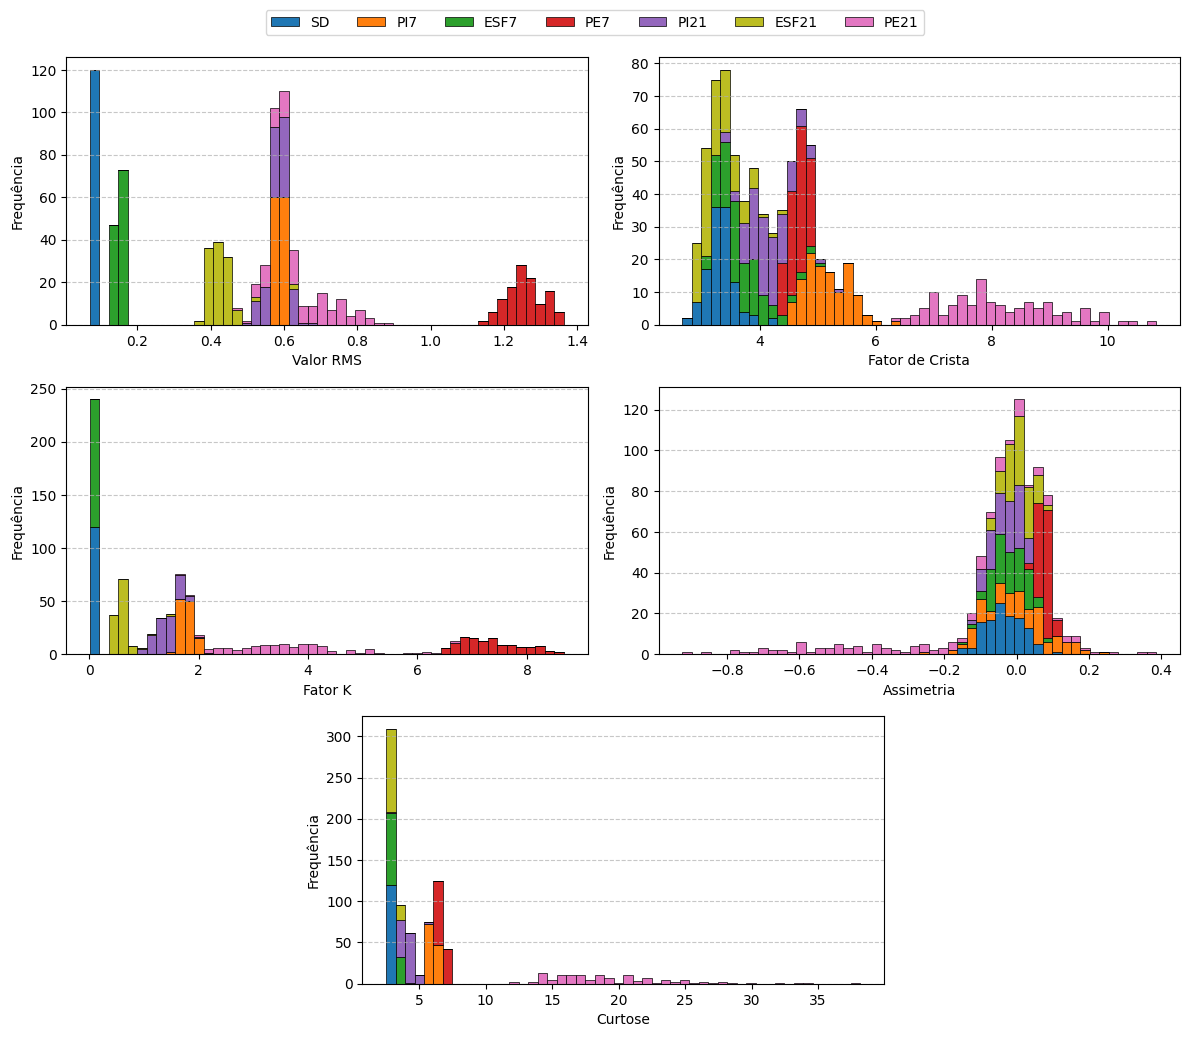

In [49]:
fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(3, 4)
list_gs = [(0,slice(0,2)),(0,slice(2,4)),(1,slice(0,2)),(1,slice(2,4))]
cores = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:olive', 'tab:pink']
for i, name in enumerate(atrib_names):
    if i==4:
        ax = fig.add_subplot(gs[2,1:3])
    else:
        ax = fig.add_subplot(gs[list_gs[i]])

    ax.hist([atributos[np.array(labels_names) == label, i] for label in classes], bins=50, alpha=1, color=cores, label=classes if i == 0 else "_nolabel_", stacked=True, edgecolor='black', linewidth=0.5)
    ax.set_xlabel(name, fontsize=10)
    ax.set_ylabel('Frequência', fontsize=10)
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
fig.legend(loc='lower center', bbox_to_anchor=(0.5, 1), ncol=len(classes))
plt.tight_layout()
# plt.savefig('LaTeX/figuras/figura_39.pdf', format='pdf', bbox_inches='tight')
plt.show()

##### **Pairplot**

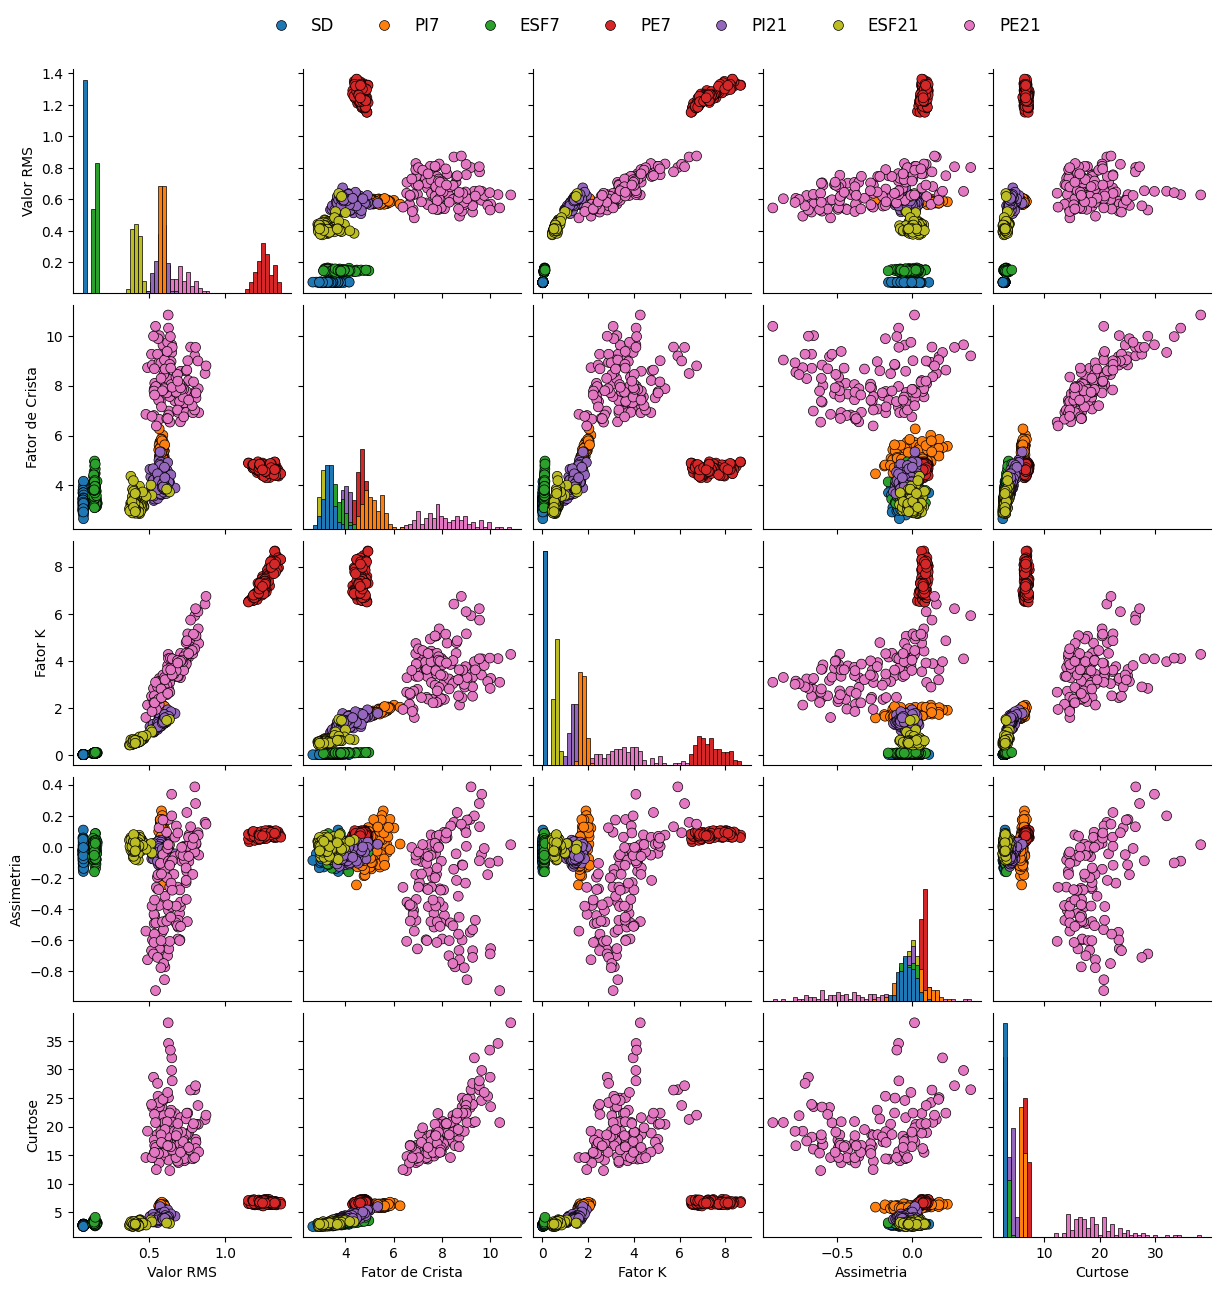

In [50]:
g = sns.pairplot(df_atributos, hue='Labels', palette=cores, corner=False, diag_kind='hist', diag_kws=dict(bins=50, edgecolor='black', alpha=1, linewidth=0.5), plot_kws=dict(s=50, edgecolor='black', alpha=1, linewidth=0.5))

sns.move_legend(g, loc='lower center', bbox_to_anchor=(0.5, 1), ncol=len(classes), title=None, fontsize=12)

# plt.savefig('LaTeX/figuras/figura_40.pdf', format='pdf', bbox_inches='tight')
plt.show()

##### **Matriz de Correlação**

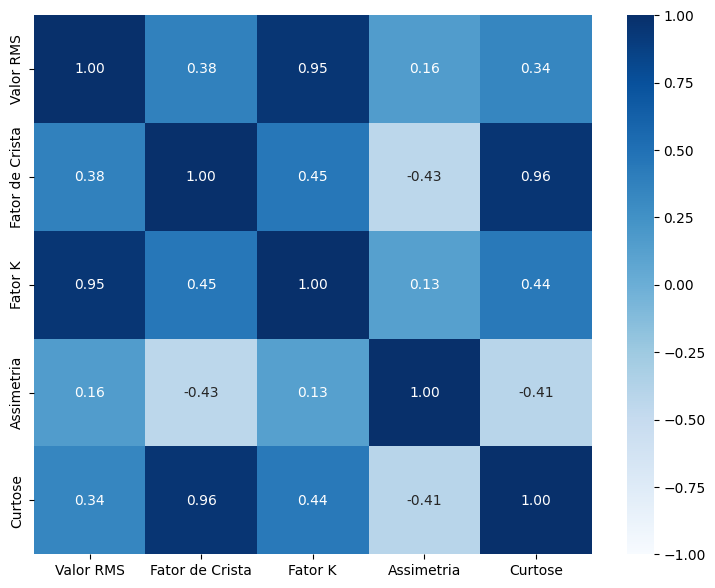

In [51]:
plt.figure(figsize=(9,7))
corr = np.corrcoef(atributos, rowvar=False)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, vmin=-1, vmax=1, annot=True, cmap='Blues', fmt='.2f', cbar=True, xticklabels=atrib_names, yticklabels=atrib_names)

# plt.savefig('LaTeX/figuras/figura_41.pdf', format='pdf', bbox_inches='tight')
plt.show()

### **Processamento dos Atributos**

#### **Padronização dos Dados**

In [52]:
# Padroniza as variáveis para média 0 e desvio padrão 1
atributos_standard = StandardScaler().fit_transform(atributos)

#### **Principal Component Analysis (PCA)**

In [53]:
# Configura a função para PCA de 2 componentes
pca = PCA(n_components=2)
# Realizar o PCA dos aributos padronizarandomizeddos com todas as variáveis
X_pca = pca.fit_transform(atributos_standard)

In [54]:
# Para X
var_explicada = pca.explained_variance_ratio_
var_acumulada = np.sum(var_explicada)
print(f"Variância explicada PC1: {100*var_explicada[0]:.2f} %")
print(f"Variância explicada PC2: {100*var_explicada[1]:.2f} %")
print(f"Variância explicada acumulada (2D PCA): {100*var_acumulada:.2f} %")

Variância explicada PC1: 56.11 %
Variância explicada PC2: 32.31 %
Variância explicada acumulada (2D PCA): 88.42 %


##### **Gráfico de Espalhamento**

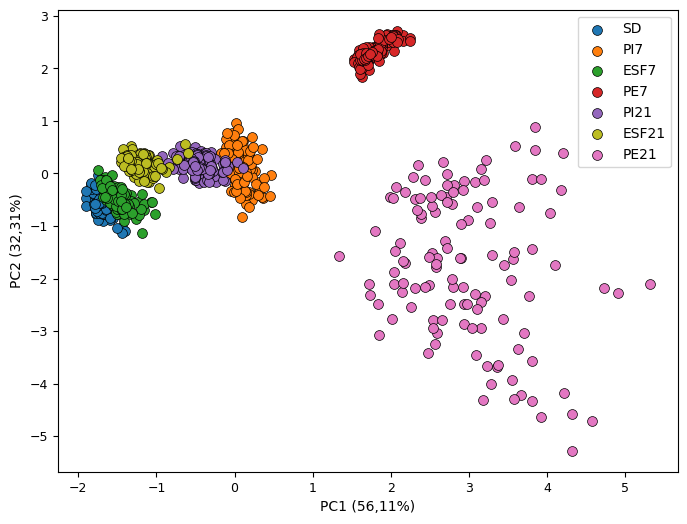

In [55]:
cores = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:olive', 'tab:pink']

plt.figure(figsize=(8,6))

for i, label in enumerate(classes):
    plt.scatter(x=X_pca[np.array(labels_names) == label, 0], y=X_pca[np.array(labels_names) == label, 1], label=label, alpha=1, color=cores[i], edgecolors='black', linewidths=0.5, s=50)
plt.xlabel('PC1 (56,11%)', fontsize=10)
plt.ylabel('PC2 (32,31%)', fontsize=10)
plt.legend(loc='upper right', fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
# plt.savefig('LaTeX/figuras/figura_42.pdf', format='pdf', bbox_inches='tight')
plt.show()

##### **Boxplot**

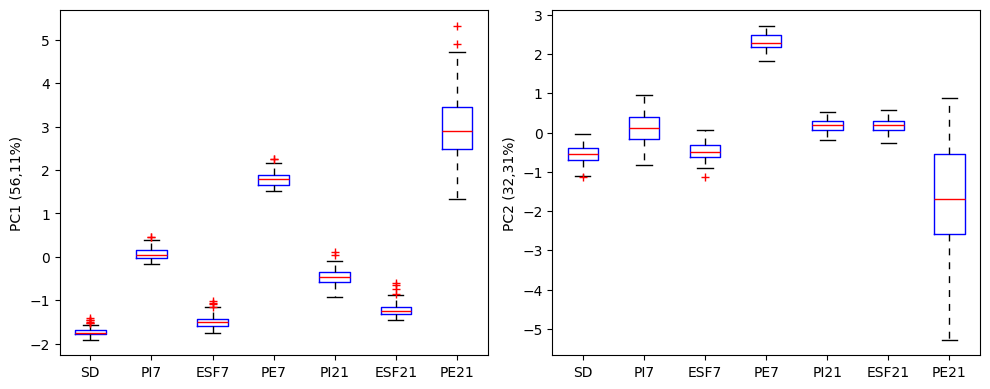

In [56]:
plt.figure(figsize=(10,4))
comp_names = ['PC1 (56,11%)', 'PC2 (32,31%)']

for i, name in enumerate(comp_names):
    boxplot = [X_pca[np.array(labels_names)==j,i] for j in classes]
    plt.subplot(1,2,i+1)
    plt.boxplot(boxplot, showfliers=True, 
                        tick_labels=classes, 
                        medianprops=dict(color='red', linewidth=1), 
                        boxprops=dict(color='blue', linewidth=1),
                        capprops=dict(linewidth=1), 
                        whiskerprops=dict(linestyle=(0, (5,5)),linewidth=1),
                        flierprops=dict(marker='+', markeredgecolor='red', markeredgewidth=1)
                )
    plt.ylabel(name, fontsize=10)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('LaTeX/figuras/figura_43.pdf', format='pdf', bbox_inches='tight')
plt.show()

#### **Clustering Hierárquico Aglomerativo**

In [57]:
Z = linkage(X_pca, method='ward', metric='euclidean')

##### **Dendrograma**

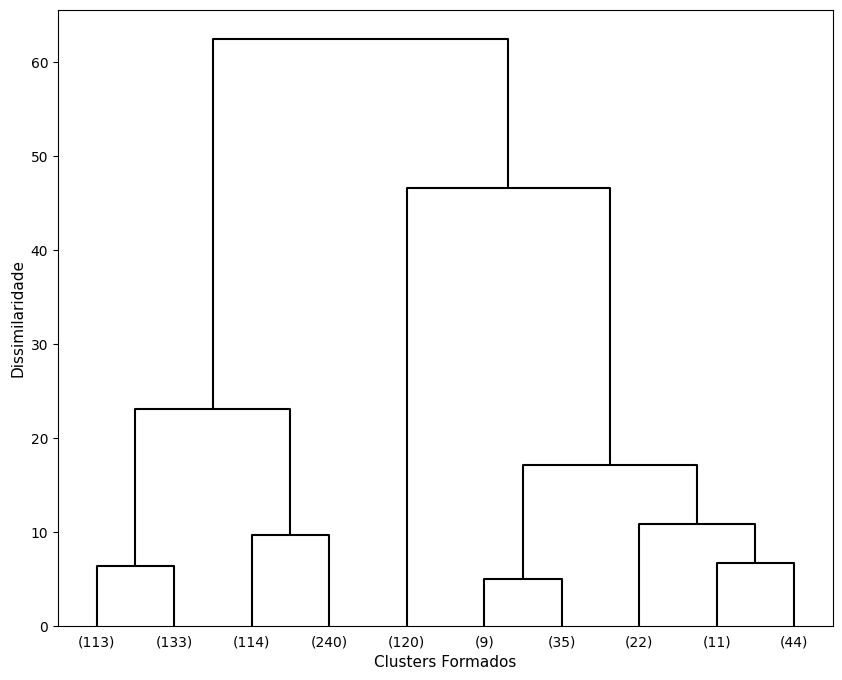

In [58]:
fig, ax = plt.subplots(figsize=(10,8))

# Dendrograma
ax = dendrogram(
    Z,
    truncate_mode='lastp', # mostra apenas os p ultimos grupos formados
    p=10, # quantos passos mostrar
    show_leaf_counts=True, # mostrar quants observações há em cada grupo entre parênteses
    leaf_rotation=0., # rotação
    leaf_font_size=9., # tamanho da fonte
    labels=list(labels_names), # rótulos do eixo x
    show_contracted=False, # to get a distribution impression in truncated branches
    above_threshold_color='black',
    color_threshold=0.1, # para que todas as linhas sejam da mesma cor
    #color_threshold=max_d, # para que os grupos fiquem com cores diferentes
)

#plt.axhline(y=max_d, c='grey', lw=1, linestyle='dashed')
plt.xlabel('Clusters Formados', fontsize=11)
plt.ylabel('Dissimilaridade', fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# plt.savefig('LaTeX/figuras/figura_44.pdf', format='pdf', bbox_inches='tight')

plt.show()

##### **Função para Rastrear as Amostras de Cada Cluster**

In [59]:
def get_cluster_samples(linkage_matrix, n_clusters, labels=None):
    """
    Rastreia as amostras em cada galho, expandindo a árvore apenas até atingir
    o número de clusters desejado.

    Argumentos:
        linkage_matrix (np.ndarray): Matriz de ligação (scipy).
        n_clusters (int): O número de clusters finais desejados (onde parar a exploração).
        labels (list, opcional): Lista de rótulos das amostras originais.

    Retorna:
        DataFrame: Tabela com a quantidade de amostras de cada classe presente em cada cluster.
    """
    n_samples = linkage_matrix.shape[0] + 1
    if labels is None:
        labels = [f'Amostra_{i}' for i in range(n_samples)]

    # Converte para estrutura de árvore
    tree = to_tree(linkage_matrix, rd=False)
    
    # Função auxiliar para pegar todas as folhas de um nó
    def get_leaves(node):
        if node.is_leaf():
            return [labels[node.get_id()]]
        return get_leaves(node.get_left()) + get_leaves(node.get_right())

    # Lista de nós ativos para exploração: tuplas (nó, id_hierarquico)
    # Iniciamos com a raiz
    active_nodes = [(tree, "1")]
    
    # Dicionário de resultados
    hierarchical_clusters = {"1": get_leaves(tree)}

    # Loop de expansão controlada
    # Continuamos dividindo enquanto o número de nós ativos for menor que o desejado
    while len(active_nodes) < n_clusters:
        # 1. Filtra apenas nós que NÃO são folhas (podem ser divididos)
        candidates = [item for item in active_nodes if not item[0].is_leaf()]
        
        if not candidates:
            break # Não há mais o que dividir
            
        # 2. Encontra o nó com a MAIOR distância (o agrupamento mais "frouxo")
        #    Isso garante que estamos cortando o dendrograma na ordem correta
        to_split = max(candidates, key=lambda item: item[0].dist)
        
        node_obj, node_id = to_split
        
        # 3. Remove o nó pai da lista de ativos (pois ele será substituído pelos filhos)
        active_nodes.remove(to_split)
        
        # 4. Obtém os filhos
        left_child = node_obj.get_left()
        right_child = node_obj.get_right()
        
        left_id = f"{node_id}.1"
        right_id = f"{node_id}.2"
        
        # 5. Adiciona os filhos aos resultados e à lista de ativos
        left_samples = get_leaves(left_child)
        right_samples = get_leaves(right_child)
        
        hierarchical_clusters[left_id] = left_samples
        hierarchical_clusters[right_id] = right_samples
        
        active_nodes.append((left_child, left_id))
        active_nodes.append((right_child, right_id))

    tabela = [[cluster.count(i) for i in np.unique(labels)] for cluster in hierarchical_clusters.values()]

    dataframe = pd.DataFrame(tabela, index=hierarchical_clusters.keys(), columns=np.unique(labels))
    
    return dataframe

##### **Tabela Final**

In [60]:
clusters_table = get_cluster_samples(linkage_matrix=Z, n_clusters=10, labels=labels_names)

clusters_table['TOTAL'] = clusters_table[classes].sum(axis=1)

clusters_table

,ESF21,ESF7,PE21,PE7,PI21,PI7,SD,TOTAL
1,120,120,121,120,120,120,120,841
1.1,120,120,0,0,120,120,120,600
1.2,0,0,121,120,0,0,0,241
1.2.1,0,0,0,120,0,0,0,120
1.2.2,0,0,121,0,0,0,0,121
1.1.1,7,0,0,0,119,120,0,246
1.1.2,113,120,0,0,1,0,120,354
1.2.2.1,0,0,44,0,0,0,0,44
1.2.2.2,0,0,77,0,0,0,0,77
1.2.2.2.1,0,0,22,0,0,0,0,22
